# CV-IPCW-HAL with Conservative Adjustment (Integrated Tuner)

This notebook demonstrates the **integrated conservative adjustment** feature in `RightCensoredOptunaHyperparameterTuner`.

## Problem: CV Oversmoothing

Cross-validation tends to select larger `norm_constraint` values than optimal, leading to **oversmoothing**. 

## Solution: Conservative 1-SE Rule

The tuner now automatically applies a conservative adjustment:
1. **Optuna Search**: Find best `norm_constraint` maximizing CV log-likelihood
2. **Conservative Adjustment**: Find smallest `norm_constraint` where `CV_LL >= max_CV_LL - k% * SD`
3. **Result**: Smaller `norm_constraint`, better KL divergence to true density

## Key Features

| Feature | Description |
|---------|-------------|
| **Default On** | `use_conservative_adjustment=True` by default |
| **Configurable** | `conservative_k_percent`, `conservative_max_steps`, `conservative_step_pct` |
| **Transparent** | Returns both `optuna_params` and `conservative_params` for comparison |
| **Opt-out** | Set `use_conservative_adjustment=False` to use raw Optuna result |


In [1]:
# Imports
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from haldensity.utils import TruncatedGMM
from haldensity.censoring import (
    # Estimators
    RightCensoredIPCWEstimator,
    # Tuners
    RightCensoredOptunaHyperparameterTuner,
    # Metrics
    kl_divergence,
    incomplete_loglik,
)

print("✓ Imports successful")


✓ Imports successful


/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Simulation

Generate right-censored data from a **truncated Gaussian Mixture Model** on [0,1]:
- True event times: `X ~ TruncatedGMM` (3 components)
- Censoring times: `C ~ Uniform(0, 1)`
- Observed: `T = min(X, C)` and `Δ = I(X ≤ C)`


In [2]:
# Simulation parameters
np.random.seed(42)
rng = np.random.default_rng(42)

n_samples = 1000

# Use the DGP class - Truncated GMM with 3 components
sampler = TruncatedGMM(
    components=[
        {"mean": 0.2, "std": 0.05, "lower": 0, "upper": 1},
        {"mean": 0.5, "std": 0.05, "lower": 0, "upper": 1},
        {"mean": 0.8, "std": 0.05, "lower": 0, "upper": 1}
    ],
    weights=[0.33, 0.34, 0.33]
)

# Generate truncated GMM event times
X_true = sampler.generate_samples(n_samples)

# Generate uniform censoring times
C = rng.uniform(0.0, 1.0, size=n_samples)

# Observed data
T = np.minimum(X_true, C)
Delta = (X_true <= C).astype(int)

# Store in DataFrame
data = pd.DataFrame({"T": T, "Delta": Delta})

# Define true_pdf_fn for evaluation
true_pdf_fn = sampler.compute_density

print(f"Sample size: {n_samples}")
print(f"Censoring rate: {(1 - Delta.mean()):.1%}")
print(f"Observed events: {Delta.sum()}")
print(f"Censored observations: {(1 - Delta).sum()}")


Sample size: 1000
Censoring rate: 48.6%
Observed events: 514
Censored observations: 486


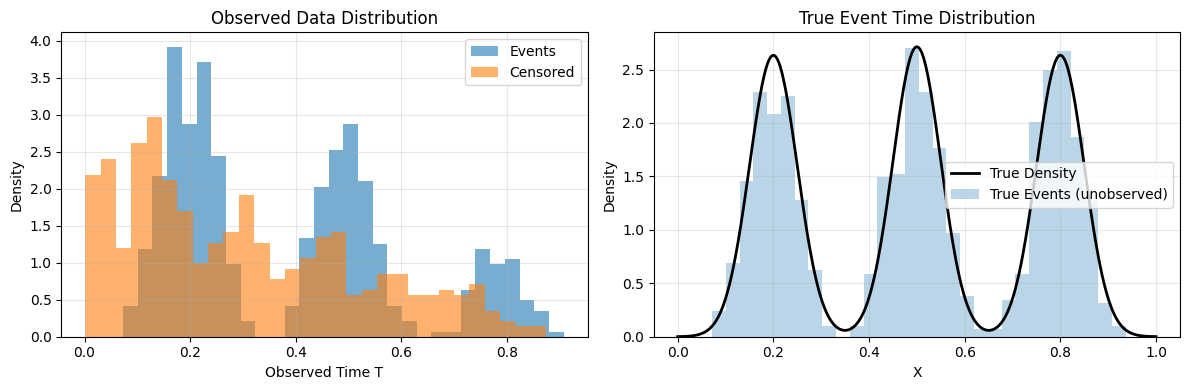

In [3]:
# Visualize data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Observed data histogram
axes[0].hist(data.loc[data['Delta'] == 1, 'T'], bins=30, alpha=0.6, label='Events', density=True)
axes[0].hist(data.loc[data['Delta'] == 0, 'T'], bins=30, alpha=0.6, label='Censored', density=True)
axes[0].set_xlabel('Observed Time T')
axes[0].set_ylabel('Density')
axes[0].set_title('Observed Data Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

# True density
grid = np.linspace(0, 1, 500)
true_density = sampler.compute_density(grid)
axes[1].plot(grid, true_density, 'k-', linewidth=2, label='True Density')
axes[1].hist(X_true, bins=30, alpha=0.3, density=True, label='True Events (unobserved)')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Density')
axes[1].set_title('True Event Time Distribution')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 2. CV Tuning with Conservative Adjustment (Default Behavior)

The tuner now **automatically applies conservative adjustment** after Optuna optimization.

Key parameters:
- `use_conservative_adjustment=True` (default) - enables the adjustment
- `conservative_k_percent=0.05` (default) - threshold is `max_CV_LL - 5% * SD`
- `conservative_max_steps=50` (default) - maximum search steps
- `conservative_step_pct=0.02` (default) - 2% step size per step


In [ ]:
# Create tuner with conservative adjustment (default: enabled)
tuner = RightCensoredOptunaHyperparameterTuner(
    estimator_name="RightCensoredIPCWEstimator",
    data=data,
    cv_folds=5,
    random_state=42,
    n_grid_points=200,
    param_overrides={
        "norm_constraint": {"low": 0.1, "high": 100.0, "log": True},
        "basis_order": [0],  # Fix basis_order to 0 for this example
    },
    # Conservative adjustment is enabled by default
    # use_conservative_adjustment=True,  # default
    # conservative_k_percent=0.05,       # default: 5% of SD
    silent=False,
)

print("Starting CV optimization with conservative adjustment...")
start_time = time.time()
result = tuner.optimize(n_trials=10)
total_time = time.time() - start_time

print(f"\n{'='*60}")
print(f"Optimization Complete")
print(f"{'='*60}")
print(f"Total time: {total_time:.2f}s")
print(f"\nOptuna CV LL: {result['best_metric_value']:.4f}")


Starting CV optimization with conservative adjustment...


Optuna CV: 100%|██████████| 10/10 [00:09<00:00,  1.03trial/s, LL=2.69, best=3.57, order=0]   



Conservative 5% SD Adjustment
Optuna best norm_constraint: 39.6761
CV LL at Optuna best: 3.5747 (SD: 4.3416)
Threshold: 3.5747 - 0.05*4.3416 = 3.3576

Searching smaller norm_constraints (step_size=0.7935)...


In [ ]:
# Compare Optuna vs Conservative results
print("="*60)
print("Comparison: Optuna vs Conservative Selection")
print("="*60)

print(f"\n{'Parameter':<25} {'Optuna':>15} {'Conservative':>15}")
print("-"*55)
print(f"{'norm_constraint':<25} {result['optuna_params']['norm_constraint']:>15.4f} {result['conservative_params']['norm_constraint']:>15.4f}")
print(f"{'basis_order':<25} {result['optuna_params']['basis_order']:>15} {result['conservative_params']['basis_order']:>15}")

reduction = result['optuna_params']['norm_constraint'] - result['conservative_params']['norm_constraint']
reduction_pct = reduction / result['optuna_params']['norm_constraint'] * 100
print("-"*55)
print(f"{'Reduction':<25} {reduction:>15.4f} ({reduction_pct:.1f}%)")

print(f"\n✓ best_params uses conservative selection by default")
print(f"  best_params['norm_constraint'] = {result['best_params']['norm_constraint']:.4f}")


In [ ]:
# Visualize the conservative adjustment search
adj_df = pd.DataFrame(result['adjustment_results'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: CV LL vs norm_constraint during adjustment
ax = axes[0]
ax.plot(adj_df['norm_constraint'], adj_df['cv_ll'], 'b-o', linewidth=2, markersize=6, label='CV Log-Likelihood')
ax.fill_between(
    adj_df['norm_constraint'],
    adj_df['cv_ll'] - adj_df['cv_sd'],
    adj_df['cv_ll'] + adj_df['cv_sd'],
    alpha=0.2, color='blue', label='±1 SD'
)

# Compute threshold for visualization
optuna_cv_ll = adj_df.iloc[0]['cv_ll']
optuna_cv_sd = adj_df.iloc[0]['cv_sd']
threshold = optuna_cv_ll - 0.05 * optuna_cv_sd

ax.axhline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.4f}')
ax.axvline(result['optuna_params']['norm_constraint'], color='orange', linestyle=':', linewidth=2, 
           label=f"Optuna NC = {result['optuna_params']['norm_constraint']:.2f}")
ax.axvline(result['conservative_params']['norm_constraint'], color='green', linestyle='-', linewidth=2, 
           label=f"Conservative NC = {result['conservative_params']['norm_constraint']:.2f}")

ax.set_xlabel('Norm Constraint', fontsize=12)
ax.set_ylabel('CV Log-Likelihood', fontsize=12)
ax.set_title('Conservative Adjustment Search', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
ax.invert_xaxis()

# Right: Above/below threshold indicator
ax = axes[1]
colors = ['green' if x else 'red' for x in adj_df['above_threshold']]
ax.bar(range(len(adj_df)), adj_df['cv_ll'], color=colors, alpha=0.7, edgecolor='black')
ax.axhline(threshold, color='red', linestyle='--', linewidth=2, label='Threshold')
ax.set_xticks(range(len(adj_df)))
ax.set_xticklabels([f"{nc:.1f}" for nc in adj_df['norm_constraint']], rotation=45, ha='right', fontsize=8)
ax.set_xlabel('Norm Constraint', fontsize=12)
ax.set_ylabel('CV Log-Likelihood', fontsize=12)
ax.set_title('CV LL by Adjustment Step (Green=Above Threshold)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## 3. Fit and Evaluate Both Models

Compare the models fitted with Optuna parameters vs Conservative parameters.


In [ ]:
# Import additional utilities for manual fitting
from haldensity.censoring import KaplanMeier, compute_ipcw_weights

# Prepare data for fitting
km = KaplanMeier().fit(data, time_col="T", delta_col="Delta")
T_vals = np.asarray(data["T"].values, dtype=float)
Delta_vals = np.asarray(data["Delta"].values, dtype=int)
ipcw_weights = compute_ipcw_weights(T_vals, Delta_vals, lambda t: np.atleast_1d(km.predict(t)))

uncensored_mask = Delta_vals == 1
ipcw_data = pd.DataFrame({"W1": T_vals[uncensored_mask]})
ipcw_weights_unc = ipcw_weights[uncensored_mask]

eval_grid = np.linspace(0, 1, 500)

# Fit model with Optuna params
print("Fitting model with Optuna parameters...")
optuna_model = RightCensoredIPCWEstimator(
    norm_constraint=result['optuna_params']['norm_constraint'],
    basis_order=result['optuna_params']['basis_order'],
    solver="ECOS",
)
optuna_model.fit(ipcw_data, sample_weights=ipcw_weights_unc)

optuna_density = optuna_model.get_density_at_points(eval_grid)
optuna_ll = incomplete_loglik(optuna_model, data, time_col="T", delta_col="Delta")
optuna_kl = kl_divergence(true_pdf_fn=true_pdf_fn, grid=eval_grid, est_density=optuna_density)

print(f"  norm_constraint: {result['optuna_params']['norm_constraint']:.4f}")
print(f"  Log-likelihood: {optuna_ll:.4f}")
print(f"  KL divergence: {optuna_kl:.4f}")

# Fit model with Conservative params (using fit_best_model for convenience)
print("\nFitting model with Conservative parameters...")
conservative_model = tuner.fit_best_model()  # Uses best_params which is conservative

conservative_density = conservative_model.get_density_at_points(eval_grid)
conservative_ll = incomplete_loglik(conservative_model, data, time_col="T", delta_col="Delta")
conservative_kl = kl_divergence(true_pdf_fn=true_pdf_fn, grid=eval_grid, est_density=conservative_density)

print(f"  norm_constraint: {result['conservative_params']['norm_constraint']:.4f}")
print(f"  Log-likelihood: {conservative_ll:.4f}")
print(f"  KL divergence: {conservative_kl:.4f}")


In [ ]:
# Summary comparison
print("="*70)
print("SUMMARY: Optuna vs Conservative Selection")
print("="*70)
print(f"\n{'Metric':<25} {'Optuna':>15} {'Conservative':>15} {'Improvement':>15}")
print("-"*70)
print(f"{'norm_constraint':<25} {result['optuna_params']['norm_constraint']:>15.4f} {result['conservative_params']['norm_constraint']:>15.4f} {result['optuna_params']['norm_constraint'] - result['conservative_params']['norm_constraint']:>+15.4f}")
print(f"{'Log-Likelihood':<25} {optuna_ll:>15.4f} {conservative_ll:>15.4f} {conservative_ll - optuna_ll:>+15.4f}")
print(f"{'KL Divergence':<25} {optuna_kl:>15.4f} {conservative_kl:>15.4f} {optuna_kl - conservative_kl:>+15.4f}")
print("-"*70)

if optuna_kl > conservative_kl:
    kl_improvement = (optuna_kl - conservative_kl) / optuna_kl * 100
    print(f"✓ Conservative selection achieves {kl_improvement:.1f}% KL improvement")
else:
    print("Note: In this case, Optuna selection had better KL (can happen with different data)")


In [ ]:
# Plot density estimates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Density comparison
ax = axes[0]
ax.plot(grid, true_density, 'k-', linewidth=3, label='True Density', alpha=0.9)
ax.plot(eval_grid, optuna_density, 'orange', linewidth=2, linestyle='--', 
        label=f'Optuna (KL={optuna_kl:.4f})', alpha=0.7)
ax.plot(eval_grid, conservative_density, 'g-', linewidth=2.5, 
        label=f'Conservative (KL={conservative_kl:.4f})', alpha=0.9)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('Density f(x)', fontsize=12)
ax.set_title('Density Estimates: Optuna vs Conservative', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Right: Absolute error comparison
ax = axes[1]
ax.plot(eval_grid, np.abs(optuna_density - true_pdf_fn(eval_grid)), 'orange', 
        linewidth=1.5, linestyle='--', label='|Optuna - True|', alpha=0.7)
ax.plot(eval_grid, np.abs(conservative_density - true_pdf_fn(eval_grid)), 'g-', 
        linewidth=2, label='|Conservative - True|', alpha=0.9)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('|Estimated - True|', fontsize=12)
ax.set_title('Absolute Error Comparison', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Opt-Out: Disable Conservative Adjustment

If you want to use the raw Optuna result without conservative adjustment, set `use_conservative_adjustment=False`.


In [ ]:
# Example: Disable conservative adjustment to use raw Optuna result
tuner_no_adjust = RightCensoredOptunaHyperparameterTuner(
    estimator_name="RightCensoredIPCWEstimator",
    data=data,
    cv_folds=5,
    random_state=42,
    param_overrides={
        "norm_constraint": {"low": 0.1, "high": 100.0, "log": True},
        "basis_order": [0],
    },
    use_conservative_adjustment=False,  # <-- Disable conservative adjustment
    silent=True,
)

result_no_adjust = tuner_no_adjust.optimize(n_trials=30)

print("With use_conservative_adjustment=False:")
print(f"  best_params = {result_no_adjust['best_params']}")
print(f"  optuna_params = {result_no_adjust['optuna_params']}")
print(f"  conservative_params = {result_no_adjust['conservative_params']}")  # Will be None
print(f"\n✓ best_params == optuna_params (conservative adjustment disabled)")


## 5. Key Takeaways

### New Tuner API with Conservative Adjustment

```python
# Default: Conservative adjustment enabled
tuner = RightCensoredOptunaHyperparameterTuner(
    estimator_name="RightCensoredIPCWEstimator",
    data=data,
    cv_folds=5,
    # use_conservative_adjustment=True,  # default
)
result = tuner.optimize(n_trials=50)

# Access results
result['optuna_params']        # Raw Optuna winner
result['conservative_params']  # Conservative-adjusted (smaller NC)
result['best_params']          # Uses conservative by default
result['adjustment_results']   # Search history for visualization
```

### Configurable Parameters

| Parameter | Default | Description |
|-----------|---------|-------------|
| `use_conservative_adjustment` | `True` | Enable/disable the adjustment |
| `conservative_k_percent` | `0.05` | Threshold = `max_CV_LL - k% * SD` |
| `conservative_max_steps` | `50` | Max search steps |
| `conservative_step_pct` | `0.02` | Step size as % of Optuna best |

### When to Use

- **Default (enabled)**: Recommended for most cases, especially with censored data
- **Disable**: When you want the exact CV-optimal parameters, or for benchmarking
